In [35]:
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

## Load & Preprocess

In [43]:
id2label = {0: "Win A", 1: "Tie", 2: "Win B"}
label2id = {v:k for k, v in id2label.items()}

model_string = "distilbert/distilbert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(
    model_string, num_labels=3, id2label=id2label, label2id=label2id
)
tokenizer = AutoTokenizer.from_pretrained(model_string)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [44]:
# limit dataset size for now
dataset = load_dataset("csv", data_files="data/train.csv")["train"]

In [45]:
def preprocess_input(batch):
    """Unifies the prompts and responses into a single sentence and creates a single integer label from the label columns."""
    prompts = []
    for prompt, resp_a, resp_b in zip(batch["prompt"], batch["response_a"], batch["response_b"]):
        prompts.append(f"<prompt>{prompt}\n\n<answer1>{resp_a}\n\n<answer2>{resp_b}")

    labels = []
    for win_a, win_b in zip(batch["winner_model_a"], batch["winner_model_b"]):
        label = 0 if win_a else 2 if win_b else 1
        labels.append(label)
    return {**tokenizer(prompts, truncation=True), "labels": labels}

In [46]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Training

- Try to check what influence certain aspects have on run time
- Run training with some configuration on increasing dataset size and log the train time

In [47]:
def get_runtime(training_arguments):
    trainer = Trainer(
        model=model,
        args=training_arguments,
        train_dataset=preprocessed,
        data_collator=data_collator
    )
    summary = trainer.train()
    return summary.metrics["train_runtime"]

### Batch Size

In [ ]:
train_store, ds_size_store, type_store = [], [], []
for dataset_size in [1000, 2000, 4000, 8000]:
    subset = dataset.select(range(dataset_size))
    preprocessed = subset.map(preprocess_input, batched=True)
    for batch_size in [1, 2, 4, 8, 16, 32, 64]:
        training_args = TrainingArguments(
            per_device_train_batch_size=batch_size,
            num_train_epochs=1,
            eval_strategy="no",
        )
        train_time = get_runtime(training_args)

        train_store.append(train_time)
        ds_size_store.append(dataset_size)
        batch_size_store.append(batch_size)

### Mixed Precision

In [48]:
train_store, ds_size_store, type_store = [], [], []
for dataset_size in [8000, 16000, 32000]:
    subset = dataset.select(range(dataset_size))
    preprocessed = subset.map(preprocess_input, batched=True)

    # Normal training with fp32
    training_args = TrainingArguments(
        per_device_train_batch_size=64,
        num_train_epochs=1,
        eval_strategy="no",
    )
    train_time = get_runtime(training_args)

    train_store.append(train_time)
    ds_size_store.append(dataset_size)
    type_store.append("fp32")

    # fp16
    training_args = TrainingArguments(
        per_device_train_batch_size=64,
        num_train_epochs=1,
        eval_strategy="no",
        fp16=True
    )
    train_time = get_runtime(training_args)

    train_store.append(train_time)
    ds_size_store.append(dataset_size)
    type_store.append("fp16")

    # bf16
    training_args = TrainingArguments(
        per_device_train_batch_size=64,
        num_train_epochs=1,
        eval_strategy="no",
        bf16=True
    )
    train_time = get_runtime(training_args)

    train_store.append(train_time)
    ds_size_store.append(dataset_size)
    type_store.append("bf16")

ValueError: Attempting to unscale FP16 gradients.

### Plot

In [32]:
import pandas as pd

# train_store, ds_size_store, batch_size_store
runtime_df = pd.DataFrame({"dataset_size": ds_size_store, "type": type_store, "runtime": train_store})
runtime_df.to_csv("runtime-tests/precision.csv")

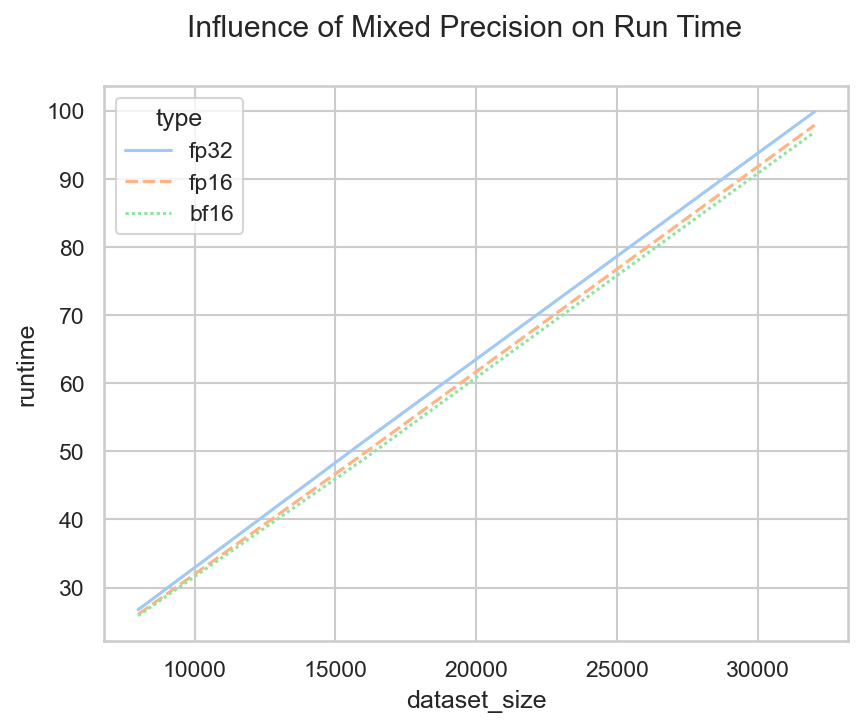

In [34]:
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
runtime_plot = sns.lineplot(runtime_df, x="dataset_size", y="runtime", hue="type", style="type")
fig = runtime_plot.get_figure()
fig.suptitle("Influence of Mixed Precision on Run Time")
fig.savefig("runtime-tests/precision.png", dpi=300)

## Inference

In [1]:
import pandas as pd
from transformers import Pipeline
from transformers.pipelines.pt_utils import KeyDataset

In [4]:
# the model gets loaded automatically after train
# only call this if no training was conducted
model = AutoModelForSequenceClassification.from_pretrained("distilbert/checkpoint-3234/")

tokenizer = AutoTokenizer.from_pretrained("distilbert/checkpoint-3234/")

In [5]:
def preprocess_for_inf(batch):
    """Unifies the prompts and responses into a single sentence and creates a single integer label from the label columns."""
    prompts = []
    for prompt, resp_a, resp_b in zip(batch["prompt"], batch["response_a"], batch["response_b"]):
        prompts.append(f"<prompt>{prompt}\n\n<answer1>{resp_a}\n\n<answer2>{resp_b}")

    return {**tokenizer(prompts, truncation=True), "text": prompts}

In [6]:
test_data = load_dataset("csv", data_files={"test": "data/test.csv"})["test"]
test_data = test_data.map(preprocess_for_inf, batched=True)

In [7]:
class SoftmaxPipeline(Pipeline):
    def preprocess(self, inputs, **kwargs):
        return self.tokenizer(inputs, return_tensors="pt", truncation=True)

    def _forward(self, model_inputs, **kwargs):
        outputs = self.model(**model_inputs)
        return outputs

    def postprocess(self, model_outputs, **kwargs):
        return model_outputs["logits"].softmax(dim=-1)

    def _sanitize_parameters(self, **kwargs):
        return {}, {}, {}

pipe = SoftmaxPipeline(task="text-classification", model=model, tokenizer=tokenizer, batch_size=4)

Device set to use cuda:0


In [11]:
from collections import defaultdict

test_result = defaultdict(list)
for sample_id, out in zip(test_data["id"], pipe(KeyDataset(test_data, "text"), batch_size=8)):
    probs = out[0].tolist()
    test_result["id"].append(sample_id)
    test_result["winner_model_a"].append(probs[0])
    test_result["winner_model_b"].append(probs[2])
    test_result["tie"].append(probs[1])

test_result = pd.DataFrame(test_result)
test_result.to_csv("submission.csv", index=False)